Imports

In [4]:
import requests
import pandas as pd
from datetime import datetime, timedelta
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib


Get the data

In [1]:
import requests

IWLS_URL = "https://api-iwls.dfo-mpo.gc.ca/api/v1/stations"

def get_top_15_nearest_stations(lat: float, lng: float) -> list[dict]:
    """
    Fetch all active stations and return the top 15 closest to the coordinates.
    """
    try:
        # Fetching fresh data directly from the provider
        response = requests.get(IWLS_URL, timeout=10)
        response.raise_for_status()
        stations = response.json()
    except Exception as exc:
        print(f"[IWLS] Failed to fetch station list: {exc}")
        return []

    # Filter for operating stations with valid coordinates
    active = [
        s for s in stations
        if s.get("operating") is True
        and s.get("latitude") is not None
        and s.get("longitude") is not None
    ]

    if not active:
        return []

    # Define the squared Euclidean distance calculation
    def _dist(s):
        return (s["latitude"] - lat) ** 2 + (s["longitude"] - lng) ** 2

    # Sort the list based on distance (ascending) and take the first 15
    sorted_stations = sorted(active, key=_dist)[:15]

    # Map to the desired dictionary structure
    return [
        {
            "id": s["id"],
            "name": s.get("officialName") or s.get("name", "Unknown station"),
            "latitude": s["latitude"],
            "longitude": s["longitude"],
            "distance_sq": _dist(s) # Optional: added to see the relative distance
        }
        for s in sorted_stations
    ]

# Usage Example:
results = get_top_15_nearest_stations(45.5017, -73.5673)
for i, station in enumerate(results, 1):
    print(f"{i}. {station['name']} (ID: {station['id']})")

1. Montréal Jetée #1 (ID: 5cebf1e03d0f4a073c4bbdd7)
2. Montréal rue Frontenac (ID: 5cebf1e03d0f4a073c4bbdee)
3. LaSalle (ID: 5dd3064de0fdc4b9b4be663c)
4. Varennes (ID: 5cebf1e03d0f4a073c4bbe04)
5. Rivière des Mille Îles (ID: 5e9f0e03ce811b0001887ac4)
6. Pointe-Claire (ID: 5cebf1e43d0f4a073c4bc480)
7. Barrage Fryer (ID: 5dd3064de0fdc4b9b4be664b)
8. Saint-Jean-sur-Richelieu (ID: 5dd3064fe0fdc4b9b4be69f8)
9. Sainte-Anne-de-Bellevue (ID: 5cebf1e43d0f4a073c4bc478)
10. Pointe-des-Cascades (ID: 5cebf1e43d0f4a073c4bc48d)
11. Contrecoeur IOC (ID: 5cebf1e03d0f4a073c4bbe1b)
12. Lanoraie (ID: 5dd3064de0fdc4b9b4be6647)
13. Sorel (ID: 5cebf1e03d0f4a073c4bbe32)
14. Lac Saint-Pierre (ID: 5cebf1e03d0f4a073c4bbe49)
15. Summerstown (ID: 5cebf1e03d0f4a073c4bbd76)


In [1]:
from datetime import datetime, timedelta, timezone

import requests

BASE_URL = "https://api-iwls.dfo-mpo.gc.ca/api/v1"

# Open-Meteo flood API for river discharge forecasts
OPEN_METEO_FLOOD_URL = "https://flood-api.open-meteo.com/v1/flood"


# ---------------------------------------------------------------------------
# Station discovery
# ---------------------------------------------------------------------------

def get_nearest_station(lat: float, lng: float) -> dict | None:
    """
    Return the nearest *active* IWLS station to the given coordinates.

    Returns a dict with keys: ``id``, ``name``, ``latitude``, ``longitude``.
    Returns ``None`` if the API call fails or no active station is found.
    """
    try:
        response = requests.get(f"{BASE_URL}/stations", timeout=10)
        response.raise_for_status()
        stations = response.json()
    except Exception as exc:
        print(f"[IWLS] Failed to fetch station list: {exc}")
        return None

    active = [
        s for s in stations
        if s.get("operating") is True
        and s.get("latitude") is not None
        and s.get("longitude") is not None
    ]

    if not active:
        return None

    def _dist(s):
        return (s["latitude"] - lat) ** 2 + (s["longitude"] - lng) ** 2

    nearest = min(active, key=_dist)
    return {
        "id": nearest["id"],
        "name": nearest.get("officialName") or nearest.get("name", "Unknown station"),
        "latitude": nearest["latitude"],
        "longitude": nearest["longitude"],
    }


# ---------------------------------------------------------------------------
# Observed water level (current)
# ---------------------------------------------------------------------------

def get_latest_water_level(
    lat: float | None = None,
    lng: float | None = None,
    station_id: str | None = None,
) -> dict | None:
    """
    Return the latest observed water level for the nearest active station.

    Provide either ``lat``/``lng`` (station is resolved automatically) or an
    explicit ``station_id``.

    Returns a dict::

        {
            "value": float,          # metres
            "station_id": str,
            "station_name": str,
            "timestamp": str,        # ISO-8601 UTC
        }

    Returns ``None`` on error.
    """
    station = _resolve_station(lat, lng, station_id)
    if station is None:
        return None

    now = datetime.now(timezone.utc)
    from_dt = now - timedelta(hours=2)

    params = {
        "time-series-code": "wlo",
        "resolution": "SIXTY_MINUTES",
        "from": from_dt.strftime("%Y-%m-%dT%H:%M:%SZ"),
        "to": now.strftime("%Y-%m-%dT%H:%M:%SZ"),
    }

    try:
        response = requests.get(
            f"{BASE_URL}/stations/{station['id']}/data",
            params=params,
            timeout=10,
        )
        response.raise_for_status()
        data = response.json()

        if not data:
            return None

        latest = max(data, key=lambda x: x["eventDate"])
        return {
            "value": float(latest["value"]),
            "station_id": station["id"],
            "station_name": station["name"],
            "timestamp": latest["eventDate"],
        }

    except Exception as exc:
        print(f"[IWLS] Failed to fetch water level: {exc}")
        return None


# ---------------------------------------------------------------------------
# Water level forecast (7 days)
# ---------------------------------------------------------------------------

def get_water_level_forecast(
    lat: float,
    lng: float,
    days: int = 7,
    station_id: str | None = None,
) -> list[dict]:
    """
    Return a daily water-level forecast for the next ``days`` days.

    Strategy
    --------
    1. Fetch the current observed water level from IWLS as an anchor.
    2. Fetch the river-discharge forecast from Open-Meteo's flood API
       (``river_discharge``) for the same coordinates.
    3. Normalise the discharge series so that today's forecasted discharge
       maps to the current observed water level, then scale the remaining
       days proportionally using a square-root relationship
       (H ∝ Q^0.5, Manning's approximation).

    Each returned dict contains::

        {
            "date": "YYYY-MM-DD",
            "water_level": float,    # estimated metres
            "river_discharge": float # m³/s from Open-Meteo
        }

    If Open-Meteo is unavailable, a flat forecast anchored at the latest
    observed level is returned so callers always get *some* data.
    """
    station = _resolve_station(lat, lng, station_id)

    # --- anchor: current observed water level ---
    anchor_level: float | None = None
    station_name = station["name"] if station else "Unknown station"
    if station:
        obs = get_latest_water_level(station_id=station["id"])
        if obs:
            anchor_level = obs["value"]

    # --- river discharge forecast from Open-Meteo ---
    discharge_series = _fetch_river_discharge(lat, lng, days)

    if not discharge_series:
        # Fallback: flat forecast
        today = datetime.now(timezone.utc).date()
        return [
            {
                "date": (today + timedelta(days=i)).isoformat(),
                "water_level": anchor_level,
                "river_discharge": None,
                "station_name": station_name,
            }
            for i in range(days)
        ]

    # --- scale discharge to water-level using Manning approximation ---
    forecast = _discharge_to_water_level(discharge_series, anchor_level, station_name)
    return forecast[:days]


# ---------------------------------------------------------------------------
# Internal helpers
# ---------------------------------------------------------------------------

def _resolve_station(
    lat: float | None,
    lng: float | None,
    station_id: str | None,
) -> dict | None:
    """Return a station dict given either coordinates or an explicit ID."""
    if station_id:
        # Minimal dict — we don't know the name without an extra API call
        return {"id": station_id, "name": "Unknown station"}
    if lat is not None and lng is not None:
        return get_nearest_station(lat, lng)
    return None


def _fetch_river_discharge(lat: float, lng: float, days: int) -> list[dict]:
    """
    Call Open-Meteo's flood API and return a list of
    ``{"date": str, "river_discharge": float}`` dicts.
    """
    try:
        params = {
            "latitude": lat,
            "longitude": lng,
            "daily": "river_discharge",
            "forecast_days": min(days, 16),  # API cap
        }
        response = requests.get(OPEN_METEO_FLOOD_URL, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()

        dates = data.get("daily", {}).get("time", [])
        discharges = data.get("daily", {}).get("river_discharge", [])

        return [
            {"date": d, "river_discharge": float(q) if q is not None else None}
            for d, q in zip(dates, discharges)
        ]
    except Exception as exc:
        print(f"[Open-Meteo Flood] Failed to fetch river discharge: {exc}")
        return []


def _discharge_to_water_level(
    discharge_series: list[dict],
    anchor_level: float | None,
    station_name: str,
) -> list[dict]:
    """
    Convert a discharge series (m³/s) to estimated water levels (m).

    Uses Manning's simplified relationship H ∝ Q^0.5 to scale around the
    anchor observation.  If ``anchor_level`` is None, discharge values are
    returned as-is (scaled to a nominal 1 m reference so the series is still
    meaningful relative to itself).
    """
    # Filter out None discharges for the scaling reference
    valid = [d["river_discharge"] for d in discharge_series if d["river_discharge"] is not None]
    if not valid:
        return [
            {**d, "water_level": anchor_level, "station_name": station_name}
            for d in discharge_series
        ]

    q_ref = valid[0]  # first forecasted day as reference
    h_ref = anchor_level if anchor_level is not None else 1.0

    result = []
    for entry in discharge_series:
        q = entry["river_discharge"]
        if q is None or q_ref is None or q_ref <= 0:
            wl = anchor_level
        else:
            # H2/H1 ≈ (Q2/Q1)^0.5
            wl = round(h_ref * ((q / q_ref) ** 0.5), 3)

        result.append(
            {
                "date": entry["date"],
                "water_level": wl,
                "river_discharge": q,
                "station_name": station_name,
            }
        )
    return result

In [6]:
print(get_nearest_station(45.612499, -73.707092))
print(get_latest_water_level(45.612499, -73.707092, '5e9f0e03ce811b0001887ac4'))
print(get_water_level_forecast(45.612499, -73.707092, 7, '5e9f0e03ce811b0001887ac4'))





{'id': '5e9f0e03ce811b0001887ac4', 'name': 'Rivière des Mille Îles', 'latitude': 45.662778, 'longitude': -73.751944}
{'value': 1.421, 'station_id': '5e9f0e03ce811b0001887ac4', 'station_name': 'Unknown station', 'timestamp': '2026-03-25T14:00:00Z'}
[{'date': '2026-03-25', 'water_level': 1.421, 'river_discharge': 2.13, 'station_name': 'Unknown station'}, {'date': '2026-03-26', 'water_level': 1.356, 'river_discharge': 1.94, 'station_name': 'Unknown station'}, {'date': '2026-03-27', 'water_level': 1.521, 'river_discharge': 2.44, 'station_name': 'Unknown station'}, {'date': '2026-03-28', 'water_level': 1.431, 'river_discharge': 2.16, 'station_name': 'Unknown station'}, {'date': '2026-03-29', 'water_level': 1.31, 'river_discharge': 1.81, 'station_name': 'Unknown station'}, {'date': '2026-03-30', 'water_level': 1.228, 'river_discharge': 1.59, 'station_name': 'Unknown station'}, {'date': '2026-03-31', 'water_level': 1.94, 'river_discharge': 3.97, 'station_name': 'Unknown station'}]


In [ ]:
def get_station_uuid(station_code):
    url = "https://api-iwls.dfo-mpo.gc.ca/api/v1/stations"
    params = {"code": station_code}
    
    response = requests.get(url, params=params)
    if response.status_code == 200:
        data = response.json()
        if data:
            print(f"Station Name: {data[0]['officialName']}")
            print(f"Station UUID: {data[0]['id']}")
            return data[0]['id']
    print("Station not found.")
    return None

# Example for Montreal 15520
get_station_uuid("15520")

In [ ]:
from datetime import datetime, timedelta, timezone
import requests

STATION_ID = "5cebf1e03d0f4a073c4bbdd7"  # Montreal Jetty No. 1 (Station 15520)
BASE_URL = f"https://api-iwls.dfo-mpo.gc.ca/api/v1/stations/{STATION_ID}/data"


def get_latest_water_level() -> float | None:
    """
    Fetches the most recent water level observation (wlo) for the station.
    Queries the last 2 hours to ensure at least one hourly reading is available.
    Returns the latest value in meters, or None if unavailable.
    """
    now = datetime.now(timezone.utc)
    from_dt = now - timedelta(hours=2)

    params = {
        "time-series-code": "wlo",
        "resolution": "SIXTY_MINUTES",
        "from": from_dt.strftime("%Y-%m-%dT%H:%M:%SZ"),
        "to": now.strftime("%Y-%m-%dT%H:%M:%SZ"),
    }

    try:
        response = requests.get(BASE_URL, params=params)
        response.raise_for_status()
        data = response.json()

        if not data:
            return None

        latest = max(data, key=lambda x: x["eventDate"])
        return float(latest["value"])

    except Exception as exc:
        print(f"[IWLS] Failed to fetch water level: {exc}")
        return None

In [ ]:
STATION_ID = "5cebf1e03d0f4a073c4bbdd7" # for Montreal Jetty No. 1 (Station 15520)
BASE_URL = f"https://api-iwls.dfo-mpo.gc.ca/api/v1/stations/{STATION_ID}/data"
PARAMS_TEMPLATE = {
    "time-series-code": "wlo",
    "resolution": "SIXTY_MINUTES"
}
START_DATE = datetime(2025, 1, 1)
END_DATE = datetime(2026, 3, 1)

def fetch_flood_data():
    all_results = []
    current_start = START_DATE
    
    print(f"Fetching hourly data from {START_DATE.date()} to {END_DATE.date()}...")

    while current_start < END_DATE:
        # Documentation states: 60 min resolution allows up to 31 days
        current_end = min(current_start + timedelta(days=31), END_DATE)
        
        params = PARAMS_TEMPLATE.copy()
        params["from"] = current_start.strftime("%Y-%m-%dT%H:%M:%SZ")
        params["to"] = current_end.strftime("%Y-%m-%dT%H:%M:%SZ")
        
        try:
            response = requests.get(BASE_URL, params=params)
            response.raise_for_status()
            data = response.json()
            
            if data:
                all_results.extend(data)
                print(f"  Batch Success: {current_start.date()} | Records: {len(data)}")
        except requests.exceptions.RequestException as e:
            print(f"  Failed at {current_start.date()}: {e}")
            break
        
        # Advance the window
        current_start = current_end
        time.sleep(0.5)

    if not all_results:
        print("No data retrieved.")
        return

    df = pd.DataFrame(all_results)
    df['eventDate'] = pd.to_datetime(df['eventDate'])
    df['Formatted Date'] = df['eventDate'].dt.strftime('%#m/%#d/%Y %#H:%M')
    final_output = df[['Formatted Date', 'value']]
    final_output.to_csv("fluvial_data/montreal_data.csv", index=False, header=False)
    
    print(f"\nFile 'montreal_data.csv' created with {len(final_output)} rows.")


fetch_flood_data()

Combine 2025-2026 data with 2015-2025 (downloaded directly on the site)

In [ ]:
# Read the downloaded 2015-2025 file which already contains headers
output_file = "fluvial_data/combined_2015_2026.csv"
old_df = pd.read_csv("fluvial_data/15520-01-JAN-2015_slev.csv")
new_df = pd.read_csv("fluvial_data/montreal_data.csv")
pd.concat([old_df, new_df], ignore_index=True).to_csv(output_file, index=False)
print(f"Combined data written to {output_file}")

Combined data written to combined_2015_2026.csv


In [ ]:
water_level_df = pd.read_csv("fluvial_data/combined_2015_2026.csv")
file_path = "weather_data/weather_with_floods_2015_2026.csv"
weather_df = pd.read_csv(file_path)

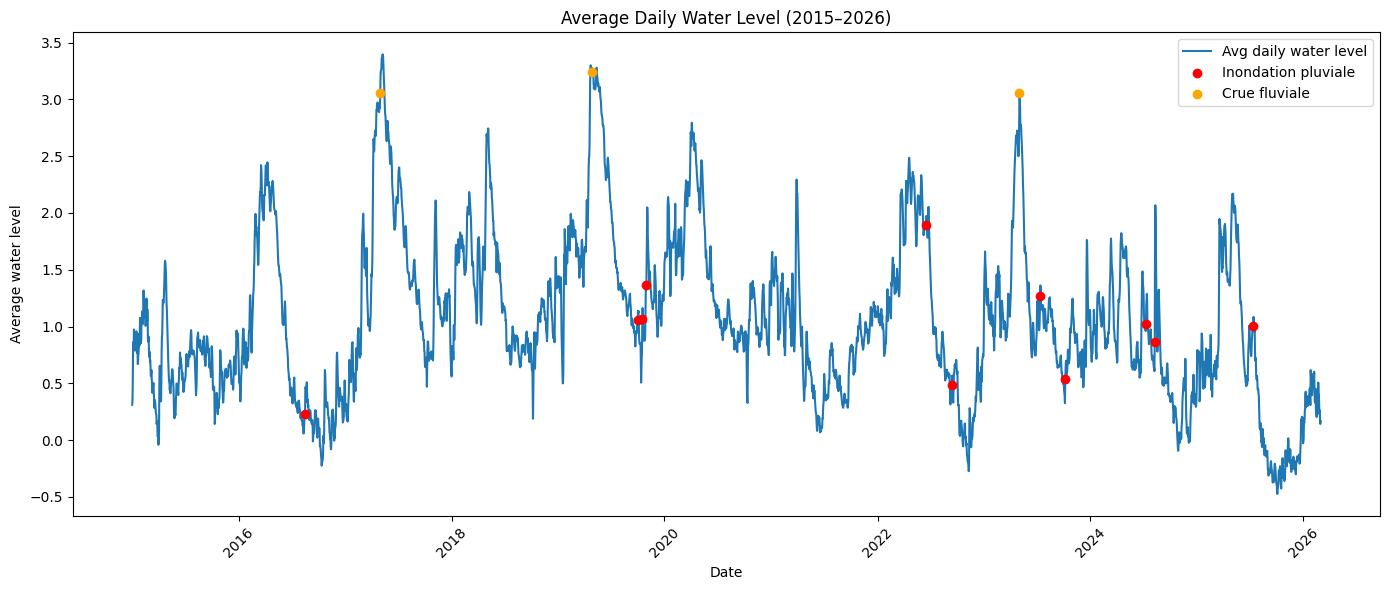

In [ ]:
# compute daily average water level and visualize
water_level_df['Formatted Date'] = pd.to_datetime(water_level_df['Date_d\'observation'])
water_level_df['Date'] = water_level_df['Formatted Date'].dt.date

# pick whichever column exists for level
daily_avg = water_level_df.groupby('Date')['SLEV(m)'].mean().reset_index()

# merge with weather dataset so we can plot even when the other dataset has no SLEV
weather_df['Date'] = pd.to_datetime(weather_df['Date/Heure']).dt.date
merged = weather_df.merge(daily_avg, on='Date', how='left')

plt.figure(figsize=(14, 6))
plt.plot(daily_avg['Date'], daily_avg['SLEV(m)'], label='Avg daily water level')
# uncomment to use bars instead of a line:
# plt.bar(daily_avg['Date'], daily_avg['SLEV(m)'], width=1, label='Avg daily water level')

# scatter flood events; merged['SLEV(m)'] may be NaN for some dates
plt.scatter(merged.loc[merged["Inondation pluviale"]==1, "Date"],
            merged.loc[merged["Inondation pluviale"]==1, "SLEV(m)"],
            color="red", label="Inondation pluviale", zorder=5)
plt.scatter(merged.loc[merged["Crue fluviale"]==1, "Date"],
            merged.loc[merged["Crue fluviale"]==1, "SLEV(m)"],
            color="orange", label="Crue fluviale", zorder=5)

plt.xlabel('Date')
plt.ylabel('Average water level')
plt.title('Average Daily Water Level (2015–2026)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
file_path = "weather_data/weather_with_floods_2015_2026.csv"
weather_df = pd.read_csv(file_path)
weather_df["Date/Heure"] = pd.to_datetime(weather_df["Date/Heure"])

water_level_df = pd.read_csv("fluvial_data/combined_2015_2026.csv")

def plot_variable_with_floods(df, variable_name):
    plot_df = df.copy()
    
    min_val = plot_df[variable_name].min()
    max_val = plot_df[variable_name].max()
    margin = (max_val - min_val) * 0.05

    plt.figure(figsize=(12, 5))

    rain_vars = ["Précip. tot. (mm)", "Rain_1d", "Rain_3d", "Rain_5d", "Rain_7d", "Rain_intensity"]
    if variable_name in rain_vars:
        plt.bar(plot_df["Date/Heure"], plot_df[variable_name], label=variable_name, width=10)
        plt.ylim(min_val, max_val + margin)

    else:
        plt.plot(plot_df["Date/Heure"], plot_df[variable_name], label=variable_name)
        plt.ylim(min_val - margin, max_val + margin)

    plt.scatter(plot_df.loc[plot_df["Inondation pluviale"]==1, "Date/Heure"],
                plot_df.loc[plot_df["Inondation pluviale"]==1, variable_name],
                color="red", label="Inondation pluviale", zorder=5)
    plt.scatter(plot_df.loc[plot_df["Crue fluviale"]==1, "Date/Heure"],
                plot_df.loc[plot_df["Crue fluviale"]==1, variable_name],
                color="orange", label="Crue fluviale", zorder=5)

    plt.xlabel("Date/Heure")
    plt.ylabel(variable_name)
    plt.title(f"{variable_name} avec les événements d'inondation (2015–2026)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [3]:
from datetime import datetime, timedelta, timezone
import requests

STATION_ID = "5cebf1e03d0f4a073c4bbdd7"  # Montreal Jetty No. 1 (Station 15520)
BASE_URL = f"https://api-iwls.dfo-mpo.gc.ca/api/v1/stations/{STATION_ID}/data"


def get_latest_water_level() -> float | None:
    """
    Fetches the most recent water level observation (wlo) for the station.
    Queries the last 2 hours to ensure at least one hourly reading is available.
    Returns the latest value in meters, or None if unavailable.
    """
    now = datetime.now(timezone.utc)
    from_dt = now - timedelta(hours=2)

    params = {
        "time-series-code": "wlo",
        "resolution": "SIXTY_MINUTES",
        "from": from_dt.strftime("%Y-%m-%dT%H:%M:%SZ"),
        "to": now.strftime("%Y-%m-%dT%H:%M:%SZ"),
    }

    try:
        response = requests.get(BASE_URL, params=params)
        response.raise_for_status()
        data = response.json()

        if not data:
            return None

        latest = max(data, key=lambda x: x["eventDate"])
        return float(latest["value"])

    except Exception as exc:
        print(f"[IWLS] Failed to fetch water level: {exc}")
        return None
    
get_latest_water_level()

0.159

In [ ]:
water_level_df = pd.read_csv("fluvial_data/combined_2015_2026.csv")
weather_df = pd.read_csv("weather_data/weather_with_floods_2015_2026.csv")

water_level_df['Formatted Date'] = pd.to_datetime(water_level_df["Date_d'observation"])
water_level_df['Date'] = water_level_df['Formatted Date'].dt.date
weather_df["Date"] = pd.to_datetime(weather_df["Date/Heure"]).dt.date

daily_avg = (
    water_level_df
    .groupby('Date')['SLEV(m)']
    .mean()
    .reset_index()
    .rename(columns={'SLEV(m)': 'Water_Level'})
)

weather_df["rain_3d"] = weather_df["Précip. tot. (mm)"].rolling(3).sum()
# weather_df["Temp_pos"] = weather_df["Temp moy.(°C)"].clip(lower=0)
# weather_df["Melt_Index"] = weather_df["Temp_pos"] * weather_df["Neige au sol (cm)"]
# weather_df["Melt_3d"] = weather_df["Melt_Index"].rolling(3).sum()

weather_df["Temp_diff_2d"] = (
    weather_df["Temp moy.(°C)"] -
    weather_df["Temp moy.(°C)"].shift(2)
)

df = weather_df.merge(daily_avg, on="Date", how="left")
df = df.dropna()
features = [
    "Water_Level",
    "rain_3d",
    # "Melt_3d",
    "Temp_diff_2d",
    "Temp moy.(°C)"
]

# =========================
# 3️⃣ EFFECT SIZE
# =========================

def effect_size(series, label):
    return (series[label == 1].mean() - series.mean()) / series.std()

effect_sizes = {
    col: effect_size(df[col], df["Crue fluviale"])
    for col in features
}

print("Effect sizes:")
for k, v in effect_sizes.items():
    print(f"{k}: {v:.3f}")

# =========================
# 4️⃣ CONVERT TO WEIGHTS
# =========================

total = sum(abs(v) for v in effect_sizes.values())

weights = {
    k: abs(v) / total
    for k, v in effect_sizes.items()
}

print("\nRelative weights:")
for k, v in weights.items():
    print(f"{k}: {v:.3f}")

scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

df["Fluvial_Score"] = sum(
    weights[col] * df[col]
    for col in features
)

Effect sizes:
Water_Level: 3.491
rain_3d: 2.120
Temp_diff_2d: 0.189
Temp moy.(°C): 1.773

Relative weights:
Water_Level: 0.461
rain_3d: 0.280
Temp_diff_2d: 0.025
Temp moy.(°C): 0.234


In [8]:
joblib.dump(scaler, "fluvial_scaler.pkl")

['fluvial_scaler.pkl']

In [9]:
gamma = 2
def compute_fluvial_probability(df, features, weights, scaler, intercept):
    X_scaled = scaler.transform(df[features])
    score = np.zeros(len(df))

    for i, col in enumerate(features):
        score += weights[col] * X_scaled[:, i]
    
    score = gamma * score + intercept

    return 1 / (1 + np.exp(-score))

In [10]:
max_score = df.loc[df["Crue fluviale"]==1, "Fluvial_Score"].max()
target_prob = 0.9
intercept = np.log(target_prob / (1 - target_prob)) - max_score
print(intercept)
df["Prob_Fluvial"] = compute_fluvial_probability(
    df,
    features,
    weights,
    scaler,
    intercept
)

# Vérification rapide
print(df[["Date", "Prob_Fluvial", "Water_Level"]].nlargest(500, 'Prob_Fluvial'))

-0.426451507691497
            Date  Prob_Fluvial  Water_Level
1578  2019-04-28      0.964669     3.544312
1573  2019-04-23      0.963188     3.584577
1572  2019-04-22      0.963040     3.542947
1576  2019-04-26      0.962214     3.492444
1577  2019-04-27      0.959822     3.460367
...          ...           ...          ...
1435  2018-12-06      0.165166     0.445884
2211  2021-01-20      0.165110     0.513449
2627  2022-03-12      0.164965     0.443154
2614  2022-02-27      0.164901     0.445201
2212  2021-01-21      0.163955     0.476595

[500 rows x 3 columns]


Test on an individual point

In [5]:
new_data = pd.DataFrame([{
    "Water_Level": 2,
    "Rain_3d": 0,
    "Melt_3d": -0.372189,
    "Temp_diff_2d": 1,
    "Temp moy.(°C)": -10
}])

prob = compute_fluvial_probability(
    new_data,
    features,
    weights,
    scaler, 
    intercept
)

print(prob)

[0.51663531]
